# Climate Scenario Temperature Paths — Scenario Generation

## Metadata

| Field | Value |
|---|---|
| Author | Lucas Monero |
| Thesis | Master Thesis |
| Notebook | `01_temperature_paths` |
| Pipeline step | Scenario generation (feeds simulation & modelling notebooks) |
| Environment | Python 3.x, numpy, pandas, scipy, matplotlib |
| Seed | N/A (fully deterministic) |

## Objective
Build daily **deterministic temperature trend paths** for 2026-2050 under
three IPCC AR6 CMIP6 SSP scenarios (Baseline ~ SSP2-4.5, SSP1-2.6, SSP5-8.5)
calibrated to northern Italy's NORD zone. Scenarios are defined by a
**time-varying warming rate**, not an additive delta, so they diverge
continuously from a shared anchor temperature at the start of 2026.

## Pipeline Position

| Inputs | This notebook | Outputs |
|---|---|---|
| `Code/Models/Temperature/temp_model_params.pkl` (fitted ERA5 trend) | Compute rate trajectories, integrate, persist | `Data/Cleaned/df_temperature_scenarios.parquet` |

## Decision Log

| # | Decision | Alternatives | Rationale | Impact |
|---|---|---|---|---|
| D1 | Baseline = ERA5 historical trend (+0.0585 C/yr) ~ SSP2-4.5 | National average, GCM ensemble mean | Fitted slope already reflects current-policy emissions trajectory | Any bias in the ERA5 fit propagates to all scenarios |
| D2 | Anchor year 2025 -- all scenarios share the same T at the start of 2026 | Anchor at 2020 or the first historical year | Ensures continuity: no discontinuity at the start of the projection | Anchor T shifts if `temp_model_params.pkl` is retrained |
| D3 | Horizon 2026-2050 | 2026-2040 or 2026-2060 | Covers the full thesis projection window | Fixed via `START_DATE`/`END_DATE` below |
| D4 | SSP1-2.6 end rate = +0.010 C/yr by 2050 | +0.020 C/yr | Near-plateau consistent with a CMIP6 SSP1-2.6 Mediterranean calibration | Temperature 2050 is ~0.6 C below Baseline |
| D5 | SSP5-8.5 end rate = +0.110 C/yr by 2050 | +0.090 C/yr | ~2x the current rate under a CMIP6 SSP5-8.5 regional high-end calibration | Temperature 2050 is ~0.6 C above Baseline |
| D6 | Rate-based scenario definition, not an additive delta | Fixed offset per scenario | More physically consistent; scenarios diverge continuously rather than shifting by a constant | Scenario spread grows non-linearly over time |
| D7 | Linear rate interpolation, 2026 to 2050 | Quadratic, step function | Parsimonious; avoids overfitting to a specific CMIP6 model run | Rate trajectory is smooth, not model-exact |

## References

- **D4 (SSP1-2.6):** "Ha et al. 2023" — cited as the source of the near-plateau
  end rate for a CMIP6 SSP1-2.6 Mediterranean calibration. No further
  bibliographic detail (journal, volume, DOI) is available in this repository;
  resolve the full citation before this notebook is treated as thesis-final.
- **D5 (SSP5-8.5):** "CMIP6 SSP5-8.5 regional high-end calibration" — no
  specific source is recorded for this notebook; the 0.110 C/yr end rate should
  be traced to a named CMIP6 regional downscaling product before publication.

Load standard libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from pathlib import Path
import pickle

Define I/O paths; create output directory if absent.

In [2]:
# ── paths ─────────────────────────────────────────────────────────────────────
models_path  = Path("../../Code/Models")
data_cleaned = Path("../../Data/Cleaned")
data_cleaned.mkdir(parents=True, exist_ok=True)

Set simulation horizon 2026–2050 (D3) and compute decimal-year index.

In [3]:
# D3: simulation horizon, 2026-2050
START_DATE = "2026-01-01"
END_DATE   = "2050-12-31"
REF_YEAR   = 2025.0   # anchor: all scenarios start from same T in 2025
 
dates_pd   = pd.date_range(start=START_DATE, end=END_DATE, freq="D")
decimal_yr = (dates_pd.year + (dates_pd.dayofyear - 1) / 365.0).values

Load fitted historical temperature trend parameters from the ERA5 model (D1).

In [4]:
# ── load historical temperature trend parameters ──────────────────────────────
with open(models_path / "Temperature" / "temp_model_params.pkl", "rb") as f:
    temp_params = pickle.load(f)

trend_slope    = float(temp_params["trend_slope"])
fourier_mean   = float(temp_params["fourier_mean"])
trend_ref_year = float(temp_params["trend_ref_year"])

print("── Climate Scenario Temperature Paths ───────────────────────────")
print(f"  Horizon          : {START_DATE} → {END_DATE}")
print(f"  Historical rate  : {trend_slope:+.5f}°C/year  (~SSP2-4.5)")
print(f"  Trend ref year   : {trend_ref_year:.0f}")
print(f"  Anchor year      : {REF_YEAR:.0f}  (scenarios share same T here)")

── Climate Scenario Temperature Paths ───────────────────────────
  Horizon          : 2026-01-01 → 2050-12-31
  Historical rate  : +0.05851°C/year  (~SSP2-4.5)
  Trend ref year   : 2005
  Anchor year      : 2025  (scenarios share same T here)


## Scenario Construction

Three warming-rate trajectories (D6) built by integrating a time-varying rate
from a shared anchor temperature (D2). Each scenario starts at the same T in
2026 and diverges over 2026-2050.

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# BASELINE — historical rate continues unchanged  (D1)
# ─────────────────────────────────────────────────────────────────────────────
# T_trend(t) = fourier_mean + trend_slope * (decimal_year - trend_ref_year)
# Identical to what the reconstruction notebook uses

T_trend_baseline = fourier_mean + trend_slope * (decimal_yr - trend_ref_year)

# D2: anchor temperature — T at the start of 2026, shared by all scenarios
T_anchor = float(T_trend_baseline[0])
print(f"\n  T_anchor (Jan 2026) : {T_anchor:.3f}°C  (all scenarios start here)")


  T_anchor (Jan 2026) : 13.921°C  (all scenarios start here)


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# SSP1-2.6 — decelerating warming rate (aggressive mitigation)
# ─────────────────────────────────────────────────────────────────────────────
# The warming rate declines linearly from the current observed rate in 2026
# toward near-stabilisation by 2050, reflecting deep emissions cuts.
# This produces a temperature in 2050 BELOW the baseline projection.
#
# Rate parameters (northern Italy, CMIP6 SSP126 regional calibration):
#   rate_2026 = trend_slope (+0.0585°C/yr, read from the pickle) — continuity at anchor
#   rate_2050 = +0.010°C/yr   (near-plateau as mitigation takes effect)

RATE_START_126 = trend_slope    # °C/year — continuity at 2026
RATE_END_126   = 0.010          # D4: near-stabilisation rate by 2050

# D6, D7: linearly declining rate — parsimonious, avoids overfitting CMIP6 models
rate_126 = RATE_START_126 + (RATE_END_126 - RATE_START_126) * \
           (decimal_yr - decimal_yr[0]) / (2050.0 - decimal_yr[0])

# integrate to get cumulative warming from anchor
cumwarm_126    = cumulative_trapezoid(rate_126, decimal_yr, initial=0)
T_trend_ssp126 = T_anchor + cumwarm_126

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# SSP5-8.5 — accelerating warming rate (fossil-fuelled development)
# ─────────────────────────────────────────────────────────────────────────────
# The warming rate increases from the current observed rate in 2026
# toward a strongly accelerating rate by 2050, reflecting continued
# fossil fuel expansion. This produces a temperature ABOVE the baseline.
#
# Rate parameters (northern Italy, CMIP6 SSP585 regional calibration):
#   rate_2026 = trend_slope (+0.0585°C/yr, read from the pickle) — continuity at anchor
#   rate_2050 = +0.110°C/yr   (~2× current rate under high emissions)

RATE_START_585 = trend_slope    # °C/year
RATE_END_585   = 0.110          # D5: ~2× current rate under high emissions

# D6, D7: linearly increasing rate — parsimonious, avoids overfitting CMIP6 models
rate_585 = RATE_START_585 + (RATE_END_585 - RATE_START_585) * \
           (decimal_yr - decimal_yr[0]) / (2050.0 - decimal_yr[0])

cumwarm_585    = cumulative_trapezoid(rate_585, decimal_yr, initial=0)
T_trend_ssp585 = T_anchor + cumwarm_585

Compute temperature delta for each scenario relative to Baseline.

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# DELTA vs BASELINE
# ─────────────────────────────────────────────────────────────────────────────
delta_ssp126 = T_trend_ssp126 - T_trend_baseline   # negative → below baseline
delta_ssp585 = T_trend_ssp585 - T_trend_baseline   # positive → above baseline

Assemble output `DataFrame` with daily trend levels, deltas, and instantaneous warming rates.

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# BUILD OUTPUT DATAFRAME
# ─────────────────────────────────────────────────────────────────────────────
df_scenarios = pd.DataFrame({
    "date":             dates_pd,
    "year":             dates_pd.year,
    "month":            dates_pd.month,
    "doy":              dates_pd.dayofyear,
    "decimal_year":     decimal_yr,
    "T_trend_baseline": T_trend_baseline,
    "T_trend_ssp126":   T_trend_ssp126,
    "T_trend_ssp585":   T_trend_ssp585,
    "delta_ssp126":     delta_ssp126,
    "delta_ssp585":     delta_ssp585,
    # instantaneous warming rates for documentation
    "rate_baseline":    trend_slope,
    "rate_ssp126":      rate_126,
    "rate_ssp585":      rate_585,
})

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# PRINT SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n── Warming rate by scenario ─────────────────────────────────────")
print(f"  {'Scenario':<12}  {'rate 2026':>10}  {'rate 2035':>10}  "
      f"{'rate 2050':>10}  {'interpretation'}")
print(f"  {'-'*12}  {'-'*10}  {'-'*10}  {'-'*10}  {'-'*25}")
for scen, rate_arr in [
    ("Baseline",  np.full(len(decimal_yr), trend_slope)),
    ("SSP1-2.6",  rate_126),
    ("SSP5-8.5",  rate_585),
]:
    r26 = float(rate_arr[df_scenarios["year"] == 2026].mean())
    r35 = float(rate_arr[df_scenarios["year"] == 2035].mean())
    r50 = float(rate_arr[df_scenarios["year"] == 2050].mean())
    interp = {"Baseline": "current policy",
              "SSP1-2.6": "aggressive mitigation",
              "SSP5-8.5": "fossil acceleration"}[scen]
    print(f"  {scen:<12}  {r26:>+9.4f}°C  {r35:>+9.4f}°C  "
          f"{r50:>+9.4f}°C  {interp}")
 
print(f"\n── Annual mean temperature trend by scenario ────────────────────")
print(f"  {'Year':>6}  {'Baseline':>10}  {'SSP1-2.6':>10}  "
      f"{'SSP5-8.5':>10}  {'Δ SSP126':>9}  {'Δ SSP585':>9}")
print(f"  {'-'*6}  {'-'*10}  {'-'*10}  "
      f"{'-'*10}  {'-'*9}  {'-'*9}")
for yr in [2026, 2030, 2035, 2040, 2045, 2050]:
    m  = df_scenarios["year"] == yr
    b  = df_scenarios.loc[m, "T_trend_baseline"].mean()
    s1 = df_scenarios.loc[m, "T_trend_ssp126"].mean()
    s5 = df_scenarios.loc[m, "T_trend_ssp585"].mean()
    d1 = s1 - b
    d5 = s5 - b
    print(f"  {yr:>6}  {b:>10.3f}°C  {s1:>10.3f}°C  "
          f"{s5:>10.3f}°C  {d1:>+9.3f}°C  {d5:>+9.3f}°C")
 
# total warming over horizon
print(f"\n── Total warming 2026 → 2050 ────────────────────────────────────")
for scen, col in [("Baseline", "T_trend_baseline"),
                   ("SSP1-2.6", "T_trend_ssp126"),
                   ("SSP5-8.5", "T_trend_ssp585")]:
    t_2026 = df_scenarios.loc[df_scenarios["year"]==2026, col].mean()
    t_2050 = df_scenarios.loc[df_scenarios["year"]==2050, col].mean()
    print(f"  {scen:<12}: {t_2026:.3f}°C → {t_2050:.3f}°C  "
          f"Δ={t_2050-t_2026:+.3f}°C")


── Warming rate by scenario ─────────────────────────────────────
  Scenario       rate 2026   rate 2035   rate 2050  interpretation
  ------------  ----------  ----------  ----------  -------------------------
  Baseline        +0.0585°C    +0.0585°C    +0.0585°C  current policy
  SSP1-2.6        +0.0575°C    +0.0393°C    +0.0090°C  aggressive mitigation
  SSP5-8.5        +0.0596°C    +0.0789°C    +0.1111°C  fossil acceleration

── Annual mean temperature trend by scenario ────────────────────
    Year    Baseline    SSP1-2.6    SSP5-8.5   Δ SSP126   Δ SSP585
  ------  ----------  ----------  ----------  ---------  ---------
    2026      13.950°C      13.950°C      13.951°C     -0.000°C     +0.000°C
    2030      14.184°C      14.164°C      14.206°C     -0.021°C     +0.022°C
    2035      14.477°C      14.386°C      14.574°C     -0.091°C     +0.097°C
    2040      14.770°C      14.557°C      14.995°C     -0.213°C     +0.226°C
    2045      15.062°C      14.678°C      15.470°C     -0

Preview first rows.

In [11]:
df_scenarios.head()

,date,year,month,doy,decimal_year,T_trend_baseline,T_trend_ssp126,T_trend_ssp585,delta_ssp126,delta_ssp585,rate_baseline,rate_ssp126,rate_ssp585
0,2026-01-01,2026,1,1,2026.000000,13.921167,13.921167,13.921167,0.000000e+00,0.000000e+00,0.05851,0.058510,0.058510
1,2026-01-02,2026,1,2,2026.002740,13.921328,13.921328,13.921328,-7.585776e-09,8.051931e-09,0.05851,0.058504,0.058515
2,2026-01-03,2026,1,3,2026.005479,13.921488,13.921488,13.921488,-3.034310e-08,3.220772e-08,0.05851,0.058498,0.058521
3,2026-01-04,2026,1,4,2026.008219,13.921648,13.921648,13.921648,-6.827198e-08,7.246737e-08,0.05851,0.058493,0.058527
4,2026-01-05,2026,1,5,2026.010959,13.921808,13.921808,13.921809,-1.213724e-07,1.288309e-07,0.05851,0.058487,0.058533


Persist scenario `DataFrame` to parquet for downstream consumption.

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# SAVE
# ─────────────────────────────────────────────────────────────────────────────
out_path = data_cleaned / "df_temperature_scenarios.parquet"
df_scenarios.to_parquet(out_path, index=False, compression="snappy")
print(f"\n  Saved : {out_path}")
print(f"  Rows  : {len(df_scenarios):,}")
print(f"  Cols  : {list(df_scenarios.columns)}")
 


  Saved : ..\..\Data\Cleaned\df_temperature_scenarios.parquet


  Rows  : 9,131
  Cols  : ['date', 'year', 'month', 'doy', 'decimal_year', 'T_trend_baseline', 'T_trend_ssp126', 'T_trend_ssp585', 'delta_ssp126', 'delta_ssp585', 'rate_baseline', 'rate_ssp126', 'rate_ssp585']


Plot temperature trend levels, scenario deltas, and warming rate trajectories.

> **What to look for:** SSP1-2.6 should diverge *below* Baseline; SSP5-8.5 *above*. The rate panel confirms deceleration vs acceleration shapes.

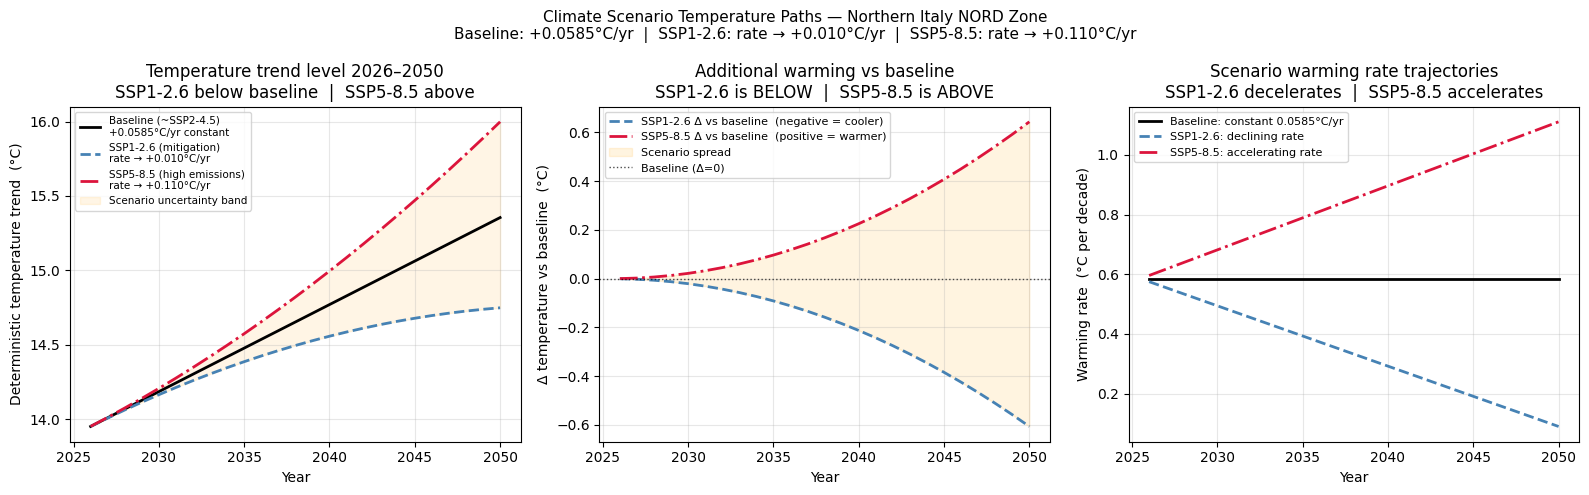

In [13]:
# PLOTS
# ─────────────────────────────────────────────────────────────────────────────
ann = df_scenarios.groupby("year")[
    ["T_trend_baseline", "T_trend_ssp126", "T_trend_ssp585",
     "rate_baseline",    "rate_ssp126",    "rate_ssp585"]
].mean().reset_index()
 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
 
# ── left: temperature trend level ─────────────────────────────────────────────
ax = axes[0]
ax.plot(ann["year"], ann["T_trend_baseline"],
        color="black",     lw=2.0, ls="-",
        label=f"Baseline (~SSP2-4.5)\n+{trend_slope:.4f}°C/yr constant")
ax.plot(ann["year"], ann["T_trend_ssp126"],
        color="steelblue", lw=2.0, ls="--",
        label=f"SSP1-2.6 (mitigation)\nrate → +{RATE_END_126:.3f}°C/yr")
ax.plot(ann["year"], ann["T_trend_ssp585"],
        color="crimson",   lw=2.0, ls="-.",
        label=f"SSP5-8.5 (high emissions)\nrate → +{RATE_END_585:.3f}°C/yr")
 
ax.fill_between(ann["year"],
                ann["T_trend_ssp126"],
                ann["T_trend_ssp585"],
                alpha=0.10, color="orange",
                label="Scenario uncertainty band")
ax.set_xlabel("Year")
ax.set_ylabel("Deterministic temperature trend  (°C)")
ax.set_title("Temperature trend level 2026–2050\n"
             "SSP1-2.6 below baseline  |  SSP5-8.5 above")
ax.legend(fontsize=7.5)
ax.grid(alpha=0.3)
 
# ── middle: delta vs baseline ─────────────────────────────────────────────────
ax = axes[1]
ax.plot(ann["year"],
        ann["T_trend_ssp126"] - ann["T_trend_baseline"],
        color="steelblue", lw=2.0, ls="--",
        label="SSP1-2.6 Δ vs baseline  (negative = cooler)")
ax.plot(ann["year"],
        ann["T_trend_ssp585"] - ann["T_trend_baseline"],
        color="crimson",   lw=2.0, ls="-.",
        label="SSP5-8.5 Δ vs baseline  (positive = warmer)")
ax.fill_between(ann["year"],
                ann["T_trend_ssp126"] - ann["T_trend_baseline"],
                ann["T_trend_ssp585"] - ann["T_trend_baseline"],
                alpha=0.12, color="orange",
                label="Scenario spread")
ax.axhline(0, color="black", lw=1.0, ls=":", alpha=0.7,
           label="Baseline (Δ=0)")
ax.set_xlabel("Year")
ax.set_ylabel("Δ temperature vs baseline  (°C)")
ax.set_title("Additional warming vs baseline\n"
             "SSP1-2.6 is BELOW  |  SSP5-8.5 is ABOVE")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
 
# ── right: warming rate trajectory ───────────────────────────────────────────
ax = axes[2]
ax.plot(ann["year"], ann["rate_baseline"] * 10,
        color="black",     lw=2.0, ls="-",
        label=f"Baseline: constant {trend_slope:.4f}°C/yr")
ax.plot(ann["year"], ann["rate_ssp126"] * 10,
        color="steelblue", lw=2.0, ls="--",
        label=f"SSP1-2.6: declining rate")
ax.plot(ann["year"], ann["rate_ssp585"] * 10,
        color="crimson",   lw=2.0, ls="-.",
        label=f"SSP5-8.5: accelerating rate")
ax.set_xlabel("Year")
ax.set_ylabel("Warming rate  (°C per decade)")
ax.set_title("Scenario warming rate trajectories\n"
             "SSP1-2.6 decelerates  |  SSP5-8.5 accelerates")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
 
plt.suptitle(
    f"Climate Scenario Temperature Paths — Northern Italy NORD Zone\n"
    f"Baseline: {trend_slope:+.4f}°C/yr  |  "
    f"SSP1-2.6: rate → {RATE_END_126:+.3f}°C/yr  |  "
    f"SSP5-8.5: rate → {RATE_END_585:+.3f}°C/yr",
    fontsize=11
)
plt.tight_layout()
plt.show()

> **Takeaway.** All three panels show the intended shape: SSP1-2.6 sits below
> Baseline and SSP5-8.5 above it in both level and delta, and the rate panel
> confirms the mechanism -- SSP1-2.6's rate decelerates toward its 2050 floor
> while SSP5-8.5's accelerates toward its ceiling. The ~0.6 C spread by 2050
> is the direct consequence of the rate choices in D4/D5.

## 10. Conclusion & Handoff

- Three daily temperature trend paths (Baseline, SSP1-2.6, SSP5-8.5) generated for 2026–2050 using a **rate-based** scenario design anchored to the ERA5 fitted trend (D1, D6).
- SSP1-2.6 ends ~0.6 °C **below** Baseline by 2050; SSP5-8.5 ends ~0.6 °C **above** (D4, D5).
- All scenarios share the same T at the start of 2026 — no discontinuity at the projection boundary (D2).
- **Next notebooks can rely on**: `Data/Cleaned/df_temperature_scenarios.parquet` — columns `date`, `year`, `month`, `doy`, `decimal_year`, `T_trend_baseline`, `T_trend_ssp126`, `T_trend_ssp585`, `delta_ssp126`, `delta_ssp585`, `rate_baseline`, `rate_ssp126`, `rate_ssp585`.